# A Parse Tree based Symbolic Regression Implementation with PyGAD

**V2** - It is the simple implementation, the objective is *X**2 + Y* 
All runs were succesful in finding the function.

**V3** - I Now Try A More Complicated Example with even more functions, the objective is *X + Y\*Tan(X/Y)* 
Some runs were able to discover the function, while some didn't.

In [1]:
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 5.8 MB/s eta 0:00:00


In [2]:
!pip list | grep -E "numpy|pandas|matplotlib|pygad"

geopandas                                1.1.3
matplotlib                               3.10.0
matplotlib-inline                        0.2.1
matplotlib-venn                          1.1.2
numpy                                    2.0.2
pandas                                   2.3.3
pandas-datareader                        0.10.0
pandas-gbq                               0.30.0
pandas-profiling                         3.6.6
pandas-stubs                             2.2.2.240909
pandasql                                 0.7.3
pygad                                    3.7.0
sklearn-pandas                           2.2.0


In [3]:
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import pygad

In [4]:
# Do Note, All Functions must be Binary for this implementation, important to remember if anyone forks this notebook and works on it.

FUNCTION_SET = {'+','-','*','/','DivSin','DivCos','DivTan'} 
TERMINAL_SET = {1,'x','y'}

In [5]:
def functionIMPL(f,x,y):
    """
    To perform the function evalutaion, while explicatly handleing potential errors.
    Can be expanded as per the function set as need be, and helps making the code modular.
    """
    
    if f == '+': return (x + y)
    if f == '-': return (x - y)
    if f == '*': return (x * y)
    if f == '/': return ((x / y) if (y != 0) else (0.0))
    if f == 'DivSin': return (math.sin((x / y) if (y != 0) else (0.0)))
    if f == 'DivCos': return (math.cos((x / y) if (y != 0) else (0.0)))
    if f == 'DivTan': return (math.tan((x / y) if (y != 0) else (0.0)))
    raise ValueError(f'Unknown Function {f!r} Encountered')

In [6]:
def random_choice(rng, collection):
    """
    Choose an element from a Python collection without allowing
    NumPy to coerce mixed types such as {1, 'x', 'y'} into strings.
    """

    values = tuple(collection)

    if not values:
        raise ValueError("Cannot choose from an empty collection.")

    index = int(rng.integers(0, len(values)))

    return values[index]

In [7]:
class Node:
    global FUNCTION_SET, TERMINAL_SET

    def __init__(self, expression):
        self.depth = 1
        self.left = None
        self.right = None
        
        if expression in FUNCTION_SET:
            self.type = 'function'
            self.function = expression

        elif expression in TERMINAL_SET:
            self.type = 'terminal'
            self.value = expression

        else: raise ValueError(f'Value {expression!r} is Illegal')

    @property
    def expression(self):
        return self.function if self.type == 'function' else self.value

    def __repr__(self):
        return (
            f"Node("
            f"{self.expression!r}, "
            f"type={self.type!r}, "
            f"depth={self.depth}"
            f")"
        )

In [8]:
class ParseTree:
    global FUNCTION_SET, TERMINAL_SET
    
    def __init__(
        self,
        *,
        tree=None,
        max_height=4,
        function_probability=0.5,
        rng=None,
        clone=True
    ):
        if not isinstance(max_height, int) or max_height < 1: raise ValueError("max_height must be a positive integer.")
        if not 0.0 <= function_probability <= 1.0: raise ValueError("function_probability must be between 0 and 1.")

        self.height_limit = max_height
        self.function_probability = function_probability

        self.rng = (rng if rng is not None else np.random.default_rng(34))

        if tree is not None:
            if not isinstance(tree, ParseTree):
                raise ValueError(
                    f"Invalid Object {type(tree)} : "
                    f"{tree} was passed"
                )
            
            self._tree = copy.deepcopy(tree._tree)

            self.height_limit = tree.height_limit
            self.function_probability = tree.function_probability

            self._refresh_metadata()

            if not clone:
                self.mutate()

            return

        self._tree = self._generate_tree(
            self.height_limit
        )

        self._refresh_metadata()
        

    def clone(self):
        """
        Return an independent ParseTree having exactly the same
        structure and values.

        The random-number generator is deliberately shared rather
        than deep-copied so cloned trees do not get identical RNG
        states.
        """

        new_tree = object.__new__(ParseTree)

        new_tree._tree = copy.deepcopy(self._tree)

        new_tree.height_limit = self.height_limit
        new_tree.function_probability = self.function_probability

        new_tree.rng = self.rng

        new_tree._refresh_metadata()

        return new_tree

    def _generate_tree(self, height_limit):
        """
        Generate a binary parse tree iteratively.

        A function node always receives exactly two children.
        Nodes at height_limit are forced to be terminals.
        """

        if (height_limit == 1 or self.rng.random() >= self.function_probability):
            root = Node(random_choice(self.rng, TERMINAL_SET))

        else:
            root = Node(random_choice(self.rng,FUNCTION_SET))

        root.depth = 1

        stack = [(root, 1)]

        while stack:
            node, depth = stack.pop()
            if node.type == "terminal": continue

            for side in ("left", "right"):

                child_depth = depth + 1

                if child_depth >= height_limit:
                    child = Node(random_choice(self.rng,TERMINAL_SET))

                elif (self.rng.random() < self.function_probability):
                    child = Node(random_choice(self.rng,FUNCTION_SET))

                else:
                    child = Node(random_choice(self.rng,TERMINAL_SET))

                child.parent = node
                child.depth = child_depth

                setattr(node, side, child)

                if child.type == "function": stack.append((child, child_depth))

        return root

    def _refresh_metadata(self):
        """
        Recalculate parent pointers, node depths and tree height.
        """

        if self._tree is None: self.max_height = 0; return

        max_height = 0

        stack = [(self._tree, None, 1)]

        while stack:
            node, parent, depth = stack.pop()

            node.parent = parent
            node.depth = depth

            max_height = max(max_height,depth)

            if node.type == "function":
                stack.append((node.left, node, depth + 1))

                stack.append((node.right, node, depth + 1))

        self.max_height = max_height

    def _nodes(self):
        """
        Return:

            (node, parent, side)

        for every node in the tree.

        side is 'left', 'right', or None for the root.
        """

        nodes = []

        stack = [(self._tree, None, None)]

        while stack:
            node, parent, side = stack.pop()

            nodes.append((node, parent, side))

            if node.right is not None: stack.append((node.right, node, "right"))

            if node.left is not None: stack.append((node.left, node, "left"))

        return nodes

    def _replace_subtree(self, parent, side, subtree):
        """
        Replace the specified subtree with another subtree.
        """

        if parent is None:
            self._tree = subtree
            subtree.parent = None

        else:
            setattr(parent,side,subtree)
            subtree.parent = parent

        self._refresh_metadata()

    def _generate_subtree(self, allowed_height):

        return ParseTree(
            max_height=allowed_height,
            function_probability=self.function_probability,
            rng=self.rng
        )._tree

    def _subtree_expression(self, root):
        """
        Iterative post-order construction of a symbolic expression.
        """

        expressions = {}

        order = [root]
        stack = [root]

        while stack:
            node = stack.pop()

            if node.type == "function":
                stack.append(node.left)
                stack.append(node.right)

            order.append(node)

        order = order[1:]
        for node in reversed(order):
            if node.type == "terminal":
                expressions[id(node)] = str(node.value)

            else:
                left_expression = expressions[id(node.left)]

                right_expression = expressions[id(node.right)]

                expressions[id(node)] = (
                    f"({left_expression} "
                    f"{node.function} "
                    f"{right_expression})"
                )

        return expressions[id(root)]

    def expression(self):
        return self._subtree_expression(self._tree)

    def __str__(self):
        return self.expression()

    def __repr__(self):
        return (
            f"ParseTree("
            f"expression={self.expression()!r}, "
            f"height={self.max_height}"
            f")"
        )

    def __call__(self, **kwargs):

        variable_terminals = {terminal for terminal in TERMINAL_SET if isinstance(terminal, str)}

        unknown = (set(kwargs) - variable_terminals)
        
        if unknown:
            raise ValueError(
                "Unknown terminal(s) supplied: "
                f"{sorted(unknown)}"
            )

        required = set()

        stack = [self._tree]

        while stack:
            node = stack.pop()

            if (node.type == "terminal"):
                 if (isinstance(node.value,str)):
                     required.add(node.value)

            else: stack.append(node.left); stack.append(node.right)

        missing = (required - set(kwargs))
        
        if missing:
            raise ValueError(f"Missing value(s) for terminal(s): {sorted(missing)}")

        order = []
        stack = [self._tree]

        while stack:
            node = stack.pop()

            order.append(node)

            if node.type == "function":
                stack.append(node.left)
                stack.append(node.right)

        results = {}

        for node in reversed(order):

            if node.type == "terminal":
                if isinstance(node.value,str): results[id(node)] = (kwargs[node.value])

                else: results[id(node)] = node.value
                    
            else:
                x = results[id(node.left)]

                y = results[id(node.right)]

                results[id(node)] = functionIMPL(node.function,x,y)

        return results[id(self._tree)]

    def _mutate_function(self):

        candidates = [item for item in self._nodes() if item[0].type == "function"]

        if not candidates: return False

        node, _, _ = random_choice(self.rng,candidates)

        alternatives = (FUNCTION_SET - {node.function})
        
        if not alternatives: return False

        node.function = random_choice(self.rng,alternatives)

        return True

    def _mutate_terminal(self):
        candidates = [item for item in self._nodes() if item[0].type == "terminal"]

        if not candidates: return False

        node, _, _ = random_choice(self.rng,candidates)

        alternatives = (TERMINAL_SET - {node.value})

        if not alternatives: return False

        node.value = random_choice(self.rng,alternatives)

        return True

    def _mutate_point(self):

        candidates = self._nodes()

        node, _, _ = random_choice(self.rng,candidates)

        if node.type == "function": return self._mutate_function_node(node)

        return self._mutate_terminal_node(node)

    def _mutate_function_node(self, node):

        alternatives = (FUNCTION_SET - {node.function})

        if not alternatives: return False

        node.function = random_choice(self.rng,alternatives)

        return True

    def _mutate_terminal_node(self, node):

        alternatives = (TERMINAL_SET - {node.value})

        if not alternatives: return False

        node.value = random_choice(self.rng,alternatives)

        return True

    def _mutate_subtree(self):

        candidates = self._nodes()

        node, parent, side = random_choice(
            self.rng,
            candidates
        )
        
        allowed_height = (self.height_limit - node.depth + 1)

        if allowed_height < 1: return False

        old_expression = self._subtree_expression(node)

        for _ in range(32):
            
            new_subtree = self._generate_subtree(allowed_height)

            if (self._subtree_expression(new_subtree) != old_expression):

                self._replace_subtree(parent,side,new_subtree)

                return True

        return False

    def mutate(
        self,
        *,
        subtree_probability=0.25,
        function_probability=0.25,
        terminal_probability=0.25,
        point_probability=0.10
    ):
        """
        Apply zero or more mutation operations according to
        the supplied probabilities.

        The important invariant is:

            AT LEAST ONE mutation will always occur.
        """

        probabilities = (
            ("subtree", subtree_probability),
            ("function", function_probability),
            ("terminal", terminal_probability),
            ("point", point_probability)
        )

        for _, probability in probabilities:

            if not 0.0 <= probability <= 1.0: raise ValueError("Mutation probabilities must be between 0 and 1.")

        changed = False

        for operation, probability in probabilities:

            if self.rng.random() >= probability:
                continue

            if operation == "subtree": changed |= self._mutate_subtree()

            elif operation == "function": changed |= self._mutate_function()

            elif operation == "terminal": changed |= self._mutate_terminal()

            elif operation == "point": changed |= self._mutate_point()

        if not changed:
            viable = []

            nodes = self._nodes()

            if any(node.type == "function" for node, _, _ in nodes): viable.append("function")

            if any(node.type == "terminal" for node, _, _ in nodes): viable.append("terminal")

            viable.extend(("subtree", "point"))

            for _ in range(32):
                operation = random_choice(self.rng,viable)

                if operation == "subtree": changed = self._mutate_subtree()

                elif operation == "function": changed = self._mutate_function()

                elif operation == "terminal": changed = self._mutate_terminal()

                else: changed = self._mutate_point()

                if changed: break

        self._refresh_metadata()

        return self

    def crossover(
        self,
        other,
        max_attempts=64
    ):
        """
        Perform subtree crossover.

        The two parents are not modified.

        Two children are returned.
        """

        if not isinstance(other, ParseTree):
            raise TypeError("crossover() requires another ParseTree.")

        for _ in range(max_attempts):

            child1 = self.clone()
            child2 = other.clone()

            nodes1 = child1._nodes()
            nodes2 = child2._nodes()

            node1, parent1, side1 = random_choice(child1.rng,nodes1)

            node2, parent2, side2 = random_choice(child2.rng,nodes2)

            subtree1 = copy.deepcopy(node1)
            subtree2 = copy.deepcopy(node2)

            child1._replace_subtree(parent1,side1,subtree2)
            child2._replace_subtree(parent2,side2,subtree1)

            if (child1.max_height <= child1.height_limit and child2.max_height <= child2.height_limit): return child1, child2

        return self.clone(), other.clone()

In [9]:
class TreePool:

    def __init__(self):
        self._trees = {}
        self._next_id = 0

    def add(self, tree):
        if not isinstance(tree, ParseTree): raise TypeError("Only ParseTree instances may be stored.")

        tree_id = self._next_id
        self._next_id += 1

        self._trees[tree_id] = tree

        return tree_id

    def get(self, tree_id):
        tree_id = int(tree_id)

        try: return self._trees[tree_id]

        except KeyError:
            raise KeyError(
                f"Unknown tree ID: {tree_id}"
            ) from None

In [10]:
def symbolic_regression_fitness(
    ga_instance,
    solution,
    solution_idx
):
    """
    PyGAD fitness function.

    Each PyGAD chromosome has exactly one gene:

        tree ID

    The tree itself lives inside TREE_POOL.
    """
    # PyGAD maximizes fitness.
    # loss = 0      --> fitness = 2
    # loss -> inf   --> fitness -> 1

    # While Invalid numerical trees get the worst fitness.

    tree_id = int(solution[0])

    tree = TREE_POOL.get(tree_id)

    try:
        predictions = np.asarray([tree(x=float(x),y=float(y)) for x, y in X_DATA],dtype=float)

        if not np.all(np.isfinite(predictions)): return 1.0

        loss = float(np.mean((predictions - Y_TARGET) ** 2))

        if not np.isfinite(loss): return 1.0

        return 1.0 + np.exp(-loss)

    except (ArithmeticError,FloatingPointError,ValueError,TypeError): return 1.0

In [11]:
def pygad_crossover(
    parents,
    offspring_size,
    ga_instance
):

    offspring = np.empty(offspring_size,dtype=int)

    for i in range(offspring_size[0]):

        parent1_id = int(parents[i % parents.shape[0],0])

        parent2_id = int(parents[(i + 1) % parents.shape[0],0])

        parent1 = TREE_POOL.get(parent1_id)

        parent2 = TREE_POOL.get(parent2_id)

        child1, child2 = parent1.crossover(parent2)

        child = (child1 if i % 2 == 0 else child2)

        offspring[i, 0] = TREE_POOL.add(child)

    return offspring

In [12]:
def pygad_mutation(
    offspring,
    ga_instance
):

    # clone=True followed by mutate guarantees that
    # the original tree remains untouched.
    mutated_offspring = np.empty(offspring.shape,dtype=int)

    for i in range(offspring.shape[0]):
        parent_id = int(offspring[i, 0])

        parent_tree = TREE_POOL.get(parent_id)
        child = parent_tree.clone()

        child.mutate()

        mutated_offspring[i, 0] = (TREE_POOL.add(child))

    return mutated_offspring

In [ ]:
# Exact target:
#       f(x, y) = x + y*Tan(x/y)

In [14]:
X_DATA = np.array([
    (-2.0, -2.0),
    (-2.0, -1.0),
    (-2.0,  0.0),
    (-2.0,  1.0),
    (-2.0,  2.0),

    (-1.0, -2.0),
    (-1.0, -1.0),
    (-1.0,  0.0),
    (-1.0,  1.0),
    (-1.0,  2.0),

    (0.0, -2.0),
    (0.0, -1.0),
    (0.0,  0.0),
    (0.0,  1.0),
    (0.0,  2.0),

    (1.0, -2.0),
    (1.0, -1.0),
    (1.0,  0.0),
    (1.0,  1.0),
    (1.0,  2.0),

    (2.0, -2.0),
    (2.0, -1.0),
    (2.0,  0.0),
    (2.0,  1.0),
    (2.0,  2.0),
], dtype=float)

Y_TARGET = np.array(
    [
        x + y*math.tan((x / y) if (y != 0) else (0.0))
        for x, y in X_DATA
    ],
    dtype=float
)

In [15]:
TREE_POOL = TreePool()

GP_RNG = np.random.default_rng(34)

POPULATION_SIZE = 50
MAX_HEIGHT = 4

initial_population = np.empty((POPULATION_SIZE, 1),dtype=int)

for i in range(POPULATION_SIZE):
    tree = ParseTree(max_height=MAX_HEIGHT,function_probability=0.50,rng=GP_RNG)

    initial_population[i, 0] = (TREE_POOL.add(tree))

In [16]:
ga_instance = pygad.GA(
    num_generations=100,
    num_parents_mating=10,
    initial_population=initial_population,
    fitness_func=symbolic_regression_fitness,
    # We are using one integer gene:
    # the ID of the ParseTree.
    gene_type=int,
    # Built-in selection is perfectly fine because selection
    # operates on the integer IDs, not the trees themselves.
    parent_selection_type="sss",
    # Our own GP operators:
    crossover_type=pygad_crossover,
    mutation_type=pygad_mutation,
    # Keep the best solutions unchanged.
    keep_elitism=2,
    # Stop immediately if exact fitness 2 is discovered.
    stop_criteria="reach_2",
    suppress_warnings=True
)

In [17]:
ga_instance.run()

In [18]:
solution, solution_fitness, solution_idx = ga_instance.best_solution()

best_tree_id = int(solution[0])

best_tree = TREE_POOL.get(best_tree_id)

print()
print("=" * 60)
print("BEST TREE")
print("=" * 60)

print("Expression :", best_tree)
print("Height     :", best_tree.max_height)
print("Fitness    :", solution_fitness)
print("Tree ID    :", best_tree_id)

print()
print("Predictions:")

for (x, y), target in zip(X_DATA,Y_TARGET):

    prediction = best_tree(x=x,y=y)

    print(
        f"x={x:>4.1f}, "
        f"y={y:>4.1f}, "
        f"target={target:>6.2f}, "
        f"prediction={prediction:>6.2f}"
    )


BEST TREE
Expression : (((x DivSin y) * (y + y)) + (x * (x DivCos y)))
Height     : 4
Fitness    : 1.6785073594494415
Tree ID    : 9515

Predictions:
x=-2.0, y=-2.0, target= -5.11, prediction= -4.45
x=-2.0, y=-1.0, target=  0.19, prediction= -0.99
x=-2.0, y= 0.0, target= -2.00, prediction= -2.00
x=-2.0, y= 1.0, target=  0.19, prediction= -0.99
x=-2.0, y= 2.0, target= -5.11, prediction= -4.45
x=-1.0, y=-2.0, target= -2.09, prediction= -2.80
x=-1.0, y=-1.0, target= -2.56, prediction= -2.22
x=-1.0, y= 0.0, target= -1.00, prediction= -1.00
x=-1.0, y= 1.0, target= -2.56, prediction= -2.22
x=-1.0, y= 2.0, target= -2.09, prediction= -2.80
x= 0.0, y=-2.0, target=  0.00, prediction=  0.00
x= 0.0, y=-1.0, target=  0.00, prediction=  0.00
x= 0.0, y= 0.0, target=  0.00, prediction=  0.00
x= 0.0, y= 1.0, target=  0.00, prediction=  0.00
x= 0.0, y= 2.0, target=  0.00, prediction=  0.00
x= 1.0, y=-2.0, target=  2.09, prediction=  2.80
x= 1.0, y=-1.0, target=  2.56, prediction=  2.22
x= 1.0, y= 0.0, 

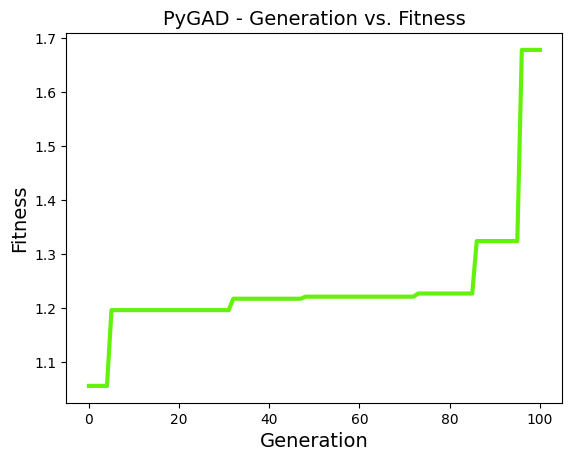

In [19]:
ga_instance.plot_fitness()
plt.show()